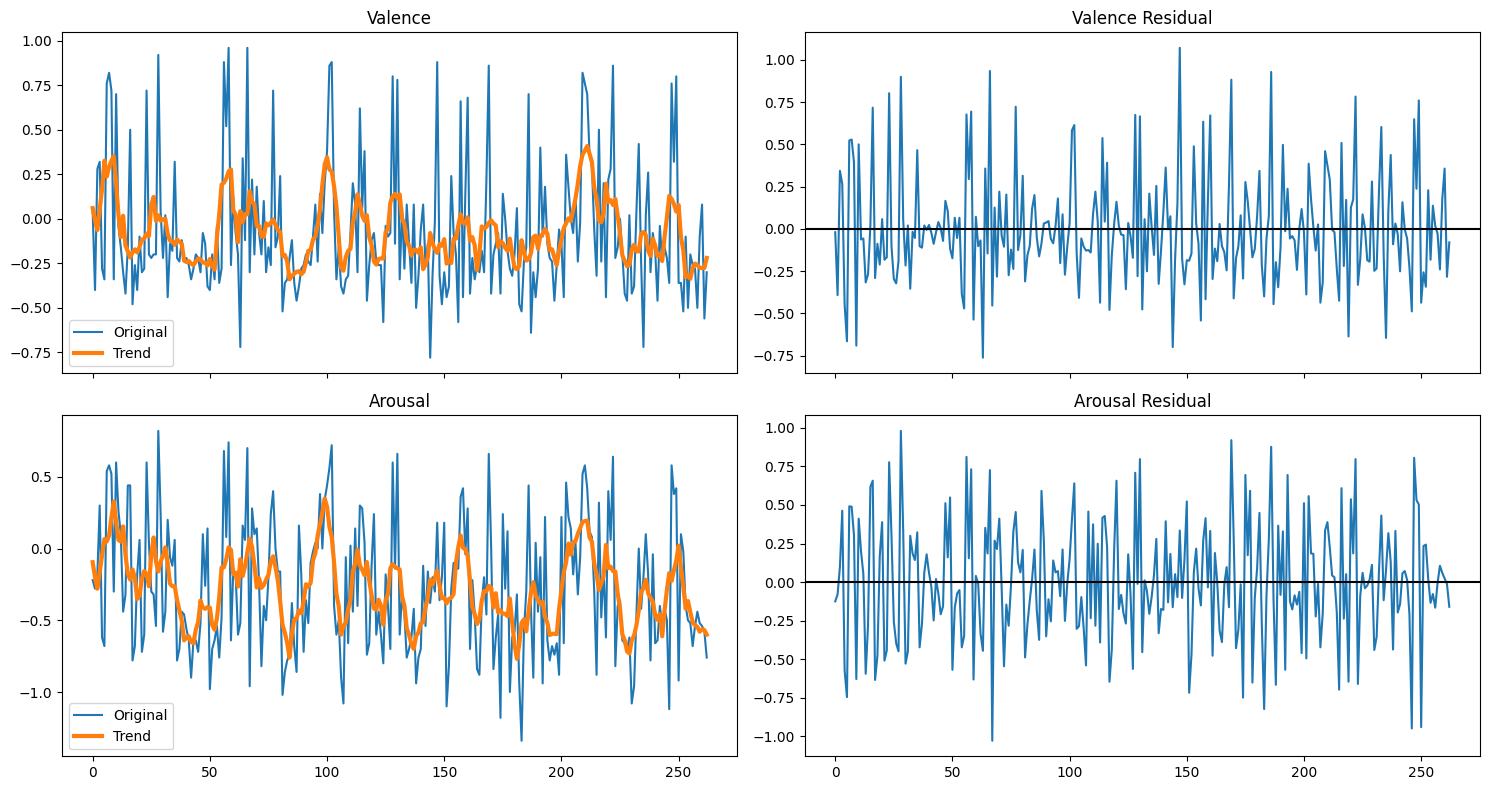

In [1]:
# 例えば5〜10発話程度の移動平均や局所回帰でトレンドを求め、そのトレンドからのずれ（急な変化）と、トレンド自体の傾き（緩やかな変化）を別々に評価
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Load
# ==========================

path = "/home/mitani/CSJ-emo-int_bunseki/0718/L_bunseki/vad_dis.csv"
df = pd.read_csv(path)

v = df["valence"].astype(float).values
a = df["arousal"].astype(float).values

# -1～1へ変換
v = v * 2 - 1
a = a * 2 - 1

# ==========================
# 移動平均
# ==========================

window = 7      # 5～10くらいで試す

v_trend = pd.Series(v).rolling(
    window,
    center=True,
    min_periods=1
).mean().values

a_trend = pd.Series(a).rolling(
    window,
    center=True,
    min_periods=1
).mean().values

# ==========================
# 急な変化（残差）
# ==========================

v_residual = v - v_trend
a_residual = a - a_trend

# ==========================
# Plot
# ==========================

fig, axes = plt.subplots(2,2, figsize=(15,8), sharex=True)

# Valence
axes[0,0].plot(v, label="Original")
axes[0,0].plot(v_trend, linewidth=3, label="Trend")
axes[0,0].set_title("Valence")
axes[0,0].legend()

axes[0,1].plot(v_residual)
axes[0,1].axhline(0,color="black")
axes[0,1].set_title("Valence Residual")

# Arousal
axes[1,0].plot(a, label="Original")
axes[1,0].plot(a_trend, linewidth=3, label="Trend")
axes[1,0].set_title("Arousal")
axes[1,0].legend()

axes[1,1].plot(a_residual)
axes[1,1].axhline(0,color="black")
axes[1,1].set_title("Arousal Residual")

plt.tight_layout()
plt.show()

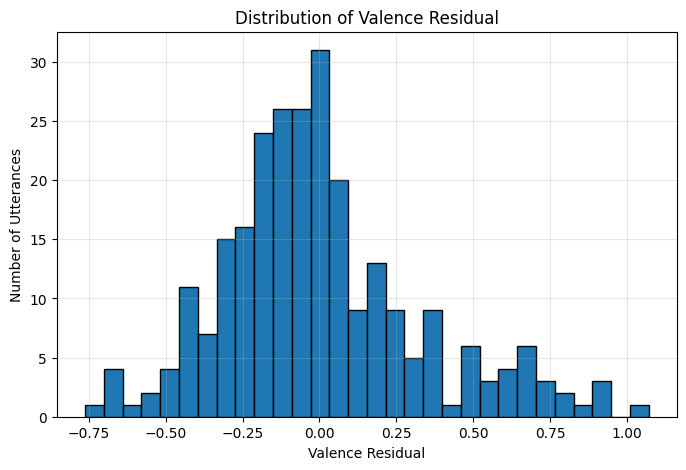

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    v_residual,
    bins=30,          # ビン数（調整可能）
    edgecolor="black"
)

plt.xlabel("Valence Residual")
plt.ylabel("Number of Utterances")
plt.title("Distribution of Valence Residual")

plt.grid(alpha=0.3)
plt.show()

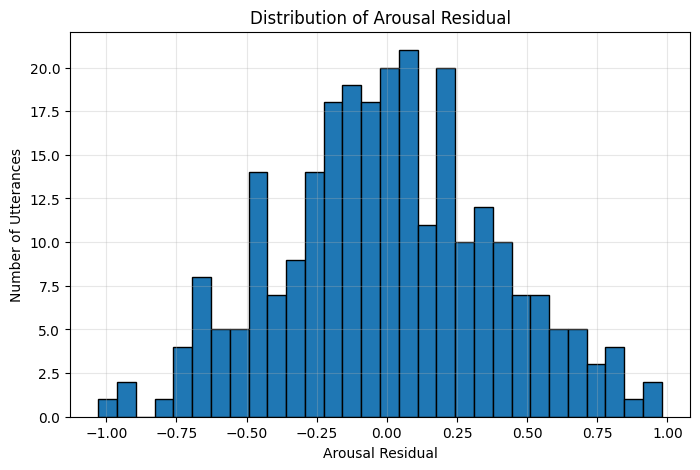

In [3]:
plt.figure(figsize=(8,5))

plt.hist(
    a_residual,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Arousal Residual")
plt.ylabel("Number of Utterances")
plt.title("Distribution of Arousal Residual")

plt.grid(alpha=0.3)
plt.show()

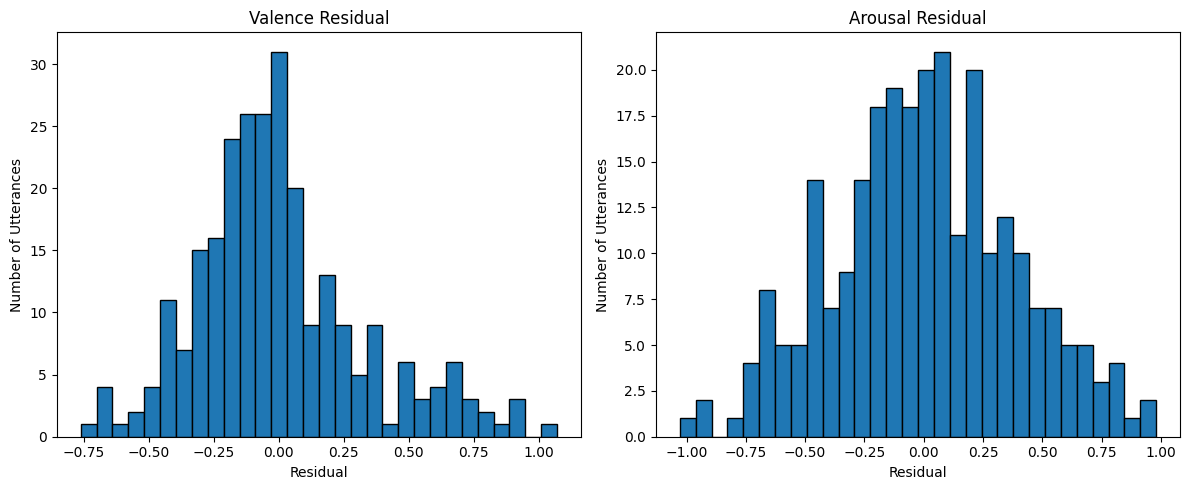

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].hist(v_residual, bins=30, edgecolor="black")
axes[0].set_title("Valence Residual")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Number of Utterances")

axes[1].hist(a_residual, bins=30, edgecolor="black")
axes[1].set_title("Arousal Residual")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Number of Utterances")

plt.tight_layout()
plt.show()

[  5   9  16  23  28  56  58  63  66  77 128 130 144 147 160 169 186 222
 247 249]


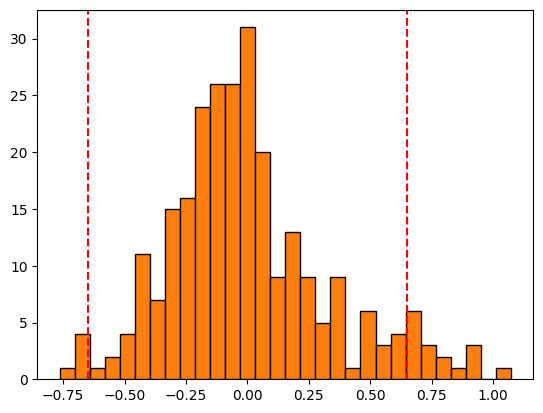

In [5]:
# 標準偏差を用いて急激な変化を検出
mean = np.mean(v_residual)
std = np.std(v_residual)

upper = mean + 2 * std
lower = mean - 2 * std

change_idx = np.where(
    (v_residual > upper) | (v_residual < lower)
)[0]

plt.hist(v_residual, bins=30)
plt.hist(v_residual, bins=30, edgecolor="black")
plt.axvline(upper, color="red", linestyle="--")
plt.axvline(lower, color="red", linestyle="--")

print(change_idx)

In [6]:
# パーセンタイルを使用して, 残差が大きい上位95%以上の発話を検出
threshold = np.percentile(np.abs(v_residual),95)

change_idx = np.where(np.abs(v_residual)>threshold)[0]
print(change_idx)

[  9  16  23  28  58  63  66  77 144 147 169 186 222 249]


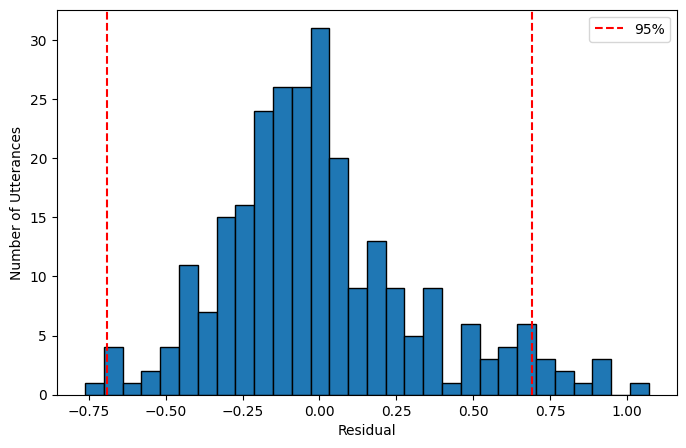

In [7]:
threshold = np.percentile(np.abs(v_residual),95)

plt.figure(figsize=(8,5))
plt.hist(v_residual, bins=30, edgecolor="black")

plt.axvline(threshold, color="red", linestyle="--", label="95%")
plt.axvline(-threshold, color="red", linestyle="--")

plt.legend()
plt.xlabel("Residual")
plt.ylabel("Number of Utterances")
plt.show()

In [8]:
# IQR（箱ひげ図を使用）
Q1 = np.percentile(v_residual,25)
Q3 = np.percentile(v_residual,75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

change_idx = np.where((v_residual<lower)|(v_residual>upper))[0]
print(change_idx)

[ 16  23  28  56  58  63  66  77 128 147 160 169 186 222 249]


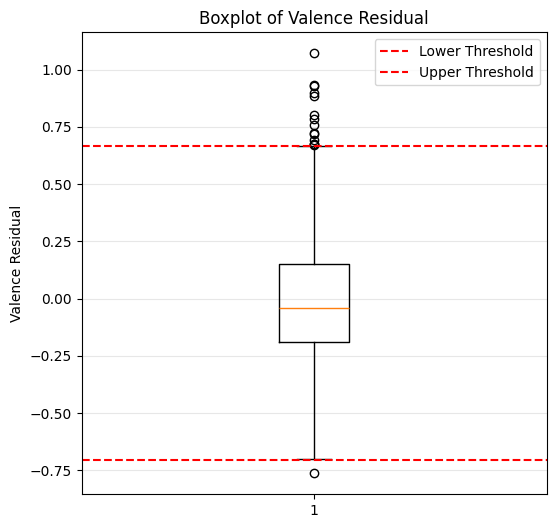

In [9]:
plt.figure(figsize=(6,6))

plt.boxplot(v_residual, showfliers=True)

plt.axhline(lower, color="red", linestyle="--", label="Lower Threshold")
plt.axhline(upper, color="red", linestyle="--", label="Upper Threshold")

plt.ylabel("Valence Residual")
plt.title("Boxplot of Valence Residual")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [10]:
print(f"検出された発話数: {len(change_idx)}")
print(f"全体に占める割合: {len(change_idx)/len(v_residual)*100:.1f}%")
print(len(change_idx))

検出された発話数: 15
全体に占める割合: 5.7%
15
